# Econ 771 - Problem Set 6
Coding Part

In [2]:
# Import necessary packages

import numpy as np
import torch
import matplotlib.pyplot as plt
import math , gc


# Iterate over a snapshot copy to avoid modifying the dict while looping
for name, obj in list(globals().items()):
    if torch.is_tensor(obj) and obj.is_cuda:
        del obj

# Empty CUDA cache
torch.cuda.empty_cache()

In [137]:
# This is for the timing of the code run time, please do not modify
import time
start_time = time.time()

In [7]:
M=1000 #Monte carlo runs
B=1000 #Bootstrap resamples
# Total loops 1 mln

#Move all computations to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Exercise I

<blockquote>

<b>

This exercise is a continuation of the Exercise I from the Problem Set 3. Consider the DGP with heteroskedastic regression errors as in part 2.

</b>

</blockquote>

<b>

1. Explore the distribution of the OLS estimator under heteroskedasticity using Eicker-White standard errors (follow steps (a)-(e)). Next, increase the sample to n = 100 observations and repeat everything. Conclude.

Reminder of PS3 part 2:

Now we introduce heteroskedasticity as follows
$$Y = \beta_1 + \beta_2 X_2 + \beta_3 X_3 + \tilde{\epsilon},$$

with coefficients set to $\beta_1 = 1$, $\beta_2 = 2$, $\beta_3 = 3$ and the data generated as $X_2 \sim N(0, 1)$, $X_3 \sim N(0, 1)$, $\epsilon \sim N(0, 1)$ with $X_2 \coprod X_3 \coprod \epsilon$, where $\tilde{\epsilon} = \epsilon(X_2 + X_3)$.

</b>

**(a) For each $m = 1, \dots, M$, compute the OLS estimator $\hat{\beta}_m = (\hat{\beta}_{1m}, \hat{\beta}_{2m}, \hat{\beta}_{3m})^T$.**

In [139]:
beta_true = torch.tensor([1.0, 2.0, 3.0], device=device)  # (β1, β2, β3)
n=20 # Use n as in PS3
#>--------------------------------------------------------

# Generate tensor of all data with dimensions M*N*K
# Create one part and duplicate it to ensure they are identical

X = torch.randn(M, n, 3, device=device) #Generate M different X matrices. of sample size n
xpx=X[:, :, 1] + X[:, :, 2]  #Creating X2 X3 term
X[:, :, 0] = X[:, :, 0] * (xpx)  #Creating the new error term
Y= X@beta_true +1.0   #  Generating the Y's
errors=X[:, :, 0].clone() # clones not to affect the original during manipulations
X[:, :, 0] = 1.0  #Replace error column with the constant column to create the features matrix


In [140]:
#Compute the estimators
# Compute estimates
XtX = X.transpose(1, 2) @ X      # shape: ( M, 3, 3)
XtX_inv = torch.linalg.inv(XtX)  # shape: ( M, 3, 3)

beta_hat= XtX_inv @ X.transpose(1, 2)@Y.view(M, n, 1) # (M,k,1)



**(b) Plot three histograms of standardized estimators assuming that $\sigma^2$ is known. Plot the probability density function of $N(0, 1)$ at each histogram.**

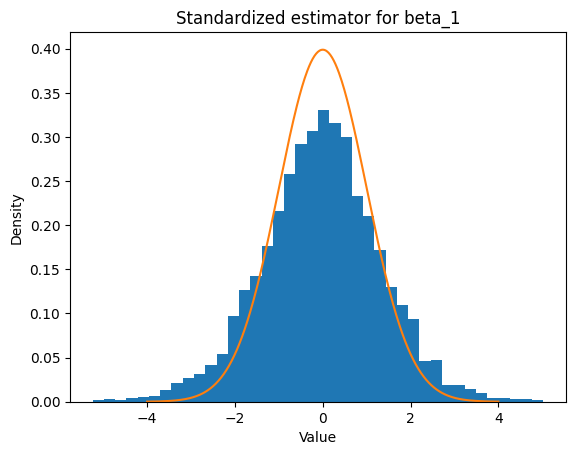

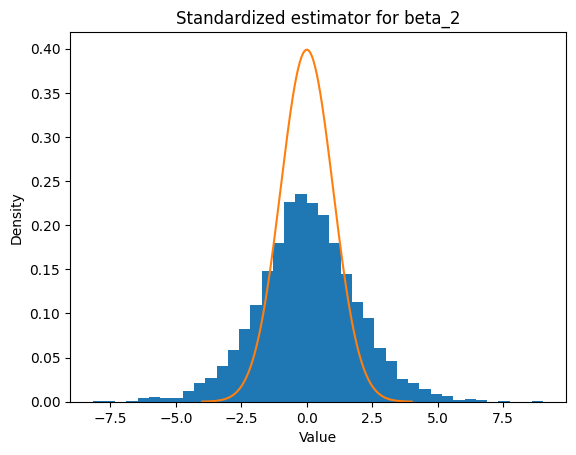

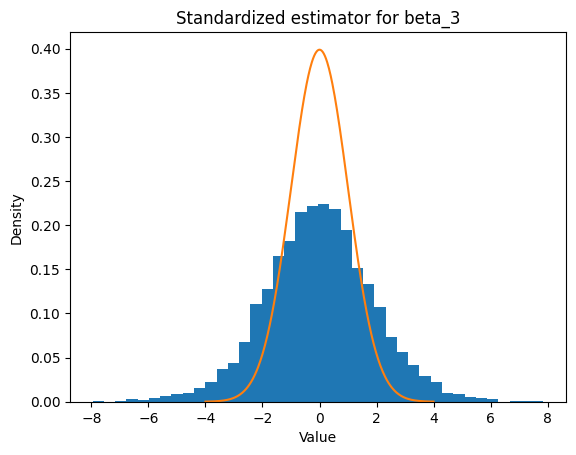

In [141]:

beta_true_cpu = torch.tensor([1.0, 2.0, 3.0], device="cpu")  # (β1, β2, β3)
n=20 # Use n as in PS3

# --- move to CPU if on CUDA ---
beta_hat_cpu = beta_hat.detach().cpu().squeeze(-1)  # (M,3)
XtX_inv_cpu = XtX_inv.detach().cpu()

sigma2 = 1.0

# --- standardize estimators ---
Z = []

for j in range(3):
    var_j = sigma2 * XtX_inv_cpu[:, j, j]
    z_j = (beta_hat_cpu[:, j] - beta_true_cpu[j]) / torch.sqrt(var_j)
    Z.append(z_j.numpy())

# --- standard normal pdf ---
def normal_pdf(x):
    return (1 / math.sqrt(2*math.pi)) * np.exp(-0.5 * x**2)

x_grid = np.linspace(-4, 4, 400)

# --- plot histograms ---
for j in range(3):
    plt.figure()
    plt.hist(Z[j], bins=40, density=True)
    plt.plot(x_grid, normal_pdf(x_grid))
    plt.title(f"Standardized estimator for beta_{j+1}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.show()

**(c) Replace $\sigma^2$ by the Eicker-White standard error estimator $\hat{\sigma}^2$ and plot histograms of $\frac{\hat{\beta}_{km} - \beta_{km}}{\sqrt{\hat{\sigma}^2 (X^T X)^{-1}}}$ with the probability function of $N(0, 1)$. What is the distribution of the standardized estimators now?**

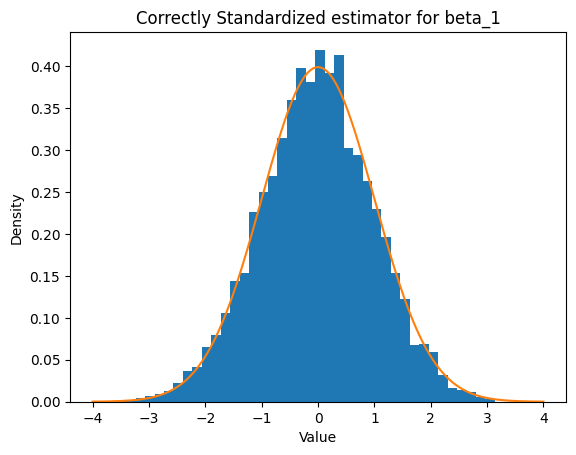

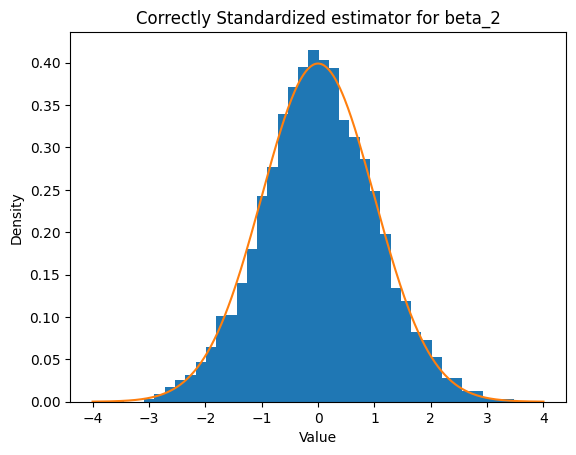

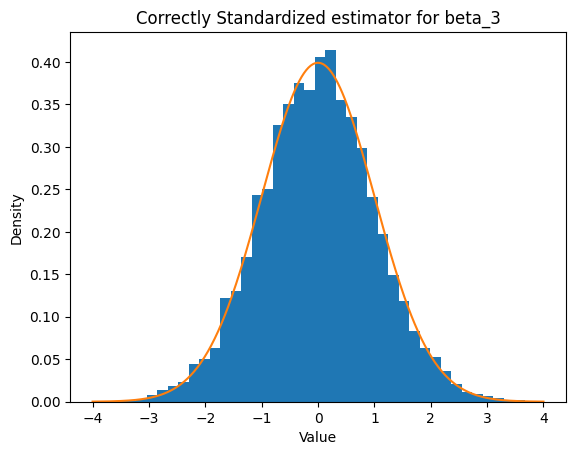

In [142]:

Z = []
X_cpu = X.detach().cpu()
for j in range(3):

    V_j = []

    for m in range(M):
        Xm = X_cpu[m]                  # (n,3)
        XtX_inv_m = XtX_inv_cpu[m]     # (3,3)

        X2 = Xm[:,1]
        X3 = Xm[:,2]

        omega_diag = sigma2 * (X2 + X3)**2
        Omega = torch.diag(omega_diag)

        V = XtX_inv_m @ Xm.T @ Omega @ Xm @ XtX_inv_m
        V_j.append(V[j, j])

    V_j = torch.stack(V_j)

    z_j = (beta_hat_cpu[:, j] - beta_true_cpu[j]) / torch.sqrt(V_j)
    Z.append(z_j.numpy())

# --- standard normal pdf ---
def normal_pdf(x):
    return (1 / math.sqrt(2*math.pi)) * np.exp(-0.5 * x**2)

x_grid = np.linspace(-4, 4, 400)

# --- plots ---
for j in range(3):
    plt.figure()
    plt.hist(Z[j], bins=40, density=True)
    plt.plot(x_grid, normal_pdf(x_grid))
    plt.title(f"Correctly Standardized estimator for beta_{j+1}")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.show()

**(d) Fix significance level at 5%. Compute the empirical size of the t-test – the fraction of times you reject the null-hypothesis when it is actually correct.**

**(e) Compute the empirical power of the t-test for the significance test ($H_0 : \beta_k = 0$) – the fraction of times you reject the null-hypothesis.**

**(f) Conclude.**

<b>

2. Now we fix the sample size at n = 30 observations. Explore empirical size and power properties (You don’t need to plot histograms for this part.) of the t-test using the following wild bootstrap procedure (you have to do the bootstrap for each Monte Carlo replication. You can try parallel computing.):

<ol>

<li> For each MC replication, $m = 1, \dots, M$, simulate the data. Estimate the linear regression coefficient $\hat{\beta}$ and compute residuals $\hat{u}$; </li>

<li> Create $B$ bootstrap samples using the wild bootstrap
$$Y_i^* = X_i^T \hat{\beta} + \eta_i \hat{u}_i, \ \ \ \ i = 1, \dots, n,$$ </li>

where $\eta_i$ are i.i.d. draws from the two-point distribution introduced in class (Please check my pdf notes in order to make sure that the you draw from the correct two-point distribution.). </li>

<li> For each bootstrap sample, estimate the linear regression coefficients $(\hat{\beta})_{b=1}^B$ and Eicker-White standard errors $\{se(\hat{\beta}_{k,b}^*) = \sqrt{\hat{V}_{k,b}^*/n}: k = 1, 2, 3, b = 1, \dots, B\}$, where $\hat{V}_{k,b}^*$ is the kth diagonal element of the Eicker-White covariance matrix estimator. Compute absolute values of t-statistics
$$T_{n,k}^b = |\frac{\hat{\beta}_{k,b}^* - \hat{\beta}}{se(\hat{\beta}_{k,b}^*)}|, \ \ \ \ b = 1, \dots, B, \ \ k = 1, 2, 3.$$ </li>

<li> Estimate 0.975th quantile of $(T_{n,k}^b)_{b=1}^B$ for k = 1, 2, 3, denoted $q_{0.975,k}^*$. </li>

<li> Reject if $T_{n,k} = |\frac{\hat{\beta}_k - \beta_{k,0}}{\sqrt{\hat{V}_k/n}}| > q_{0.975,k}^*$ (It is recommended to impose symmetry for quantiles as long as the asymptotic distribution is symmetric, e.g., N(0, 1).). </li>

</ol>

</b>

In [8]:
n=30

#generate my coinflip tensor

beta_true = torch.tensor([1.0, 2.0, 3.0], device=device)  # (β1, β2, β3)

X = torch.randn(M, n, 3, device=device) #Generate M different X matrices. of sample size n
xpx=X[:, :, 1] + X[:, :, 2]  #Creating X2 X3 term
X[:, :, 0] = X[:, :, 0] * (xpx)  #Creating the new error term
Y= X@beta_true +1.0   #  Generating the Y's
errors=X[:, :, 0].clone() # clones not to affect the original during manipulations
X[:, :, 0] = 1.0  #Replace error column with the constant column to create the features matrix



In [27]:
#Estimate beta_hat and u_hat
XtX = X.transpose(1, 2) @ X      # shape: ( M, k, k)
XtX_inv = torch.linalg.inv(XtX)  # shape: ( M, k, k)
beta_hat= XtX_inv @ X.transpose(1, 2)@Y.view(M, n, 1) # ( M, k, 1)
Y_fitted = X @ beta_hat
u_hat = Y.view(M, n, 1) - Y_fitted #


In [29]:
btp = torch.randint(0, 2, (M, B, n, 1), device='cuda').mul_(2).sub_(1)



u_star = u_hat.unsqueeze(1) * btp # (M, B, n, 1)
          # (M, n, 1)

Y_star = Y_fitted.unsqueeze(1) + u_star
# (M, B, n, 1)




In [31]:

XtY_star = X.transpose(1,2).unsqueeze(1) @ Y_star
# (M, B, k, 1)

beta_star = XtX_inv.unsqueeze(1) @ XtY_star
# (M, B, k, 1)

u_star_hat = Y_star - X.unsqueeze(1) @ beta_star

In [37]:
# square residuals
u2 = u_star_hat.squeeze(-1)**2                    # (M, B, n)

# form X' diag(u^2) X efficiently
middle = (
    X.unsqueeze(1).transpose(-1, -2)
    @ (X.unsqueeze(1) * u2.unsqueeze(-1))
)                                                 # (M, B, k, k)

# sandwich
XtX_inv_exp = XtX_inv.unsqueeze(1)                # (M, 1, k, k)
V_hat = XtX_inv_exp @ middle @ XtX_inv_exp       # (M, B, k, k)

se_star = (
    V_hat.diagonal(dim1=-2, dim2=-1) / n
).sqrt()                                          # (M, B, k)

In [40]:
# reshape original beta_hat
beta_hat_exp = beta_hat.unsqueeze(1)              # (M, 1, k, 1)

# difference
diff = (beta_star - beta_hat_exp).squeeze(-1)     # (M, B, k)

# t statistics
T = (diff / se_star).abs()                        # (M, B, k)

In [42]:
#The quantile
q_star = torch.quantile(T, 0.975, dim=1)

In [44]:
q_star.shape

torch.Size([1000, 3])

**3. Compare your results for the finite-sample approach (PS 3), the asymptotic approach (Eicker-White), and the bootstrap.**

In [ ]:
beta_star

# final jecection should be over original estimations

In [ ]:
# This is for the timing of the code run time, please do not modify
end_time = time.time()

print(f"Total runtime: {end_time - start_time} seconds")